# Discovering Brisbane Weather Regimes with a Hidden Markov Model

## Project overview

Weather does not change as a sequence of completely independent days. Hot and humid conditions may persist for several days, wet systems may arrive and leave together, and cooler dry periods often occur as continuous spells.

This project uses a **Gaussian Hidden Markov Model (HMM)** to discover recurring latent weather regimes in Brisbane without using predefined weather labels.

Unlike conventional clustering, an HMM considers both:

- the meteorological characteristics of each day;
- the probability of transitioning from one hidden regime to another.

## Main questions

1. How many latent weather regimes are supported by the data?
2. What meteorological conditions define each regime?
3. Which regimes are most common during different months?
4. How persistent is each regime?
5. Which transitions are common or unusual?
6. On which days is the model uncertain about the regime?

## Methods

- NASA POWER daily meteorological data
- Weather-feature engineering
- Gaussian Hidden Markov Models
- Multi-seed model fitting
- Bayesian Information Criterion
- Latent-state profiling
- Transition and spell-duration analysis
- Posterior uncertainty analysis

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)

RANDOM_STATE = 42

## 1. Download the weather data

Daily meteorological observations are retrieved from the NASA POWER API for Brisbane, Australia.

The selected variables represent:

- mean, maximum, and minimum temperature;
- relative humidity;
- corrected precipitation;
- wind speed;
- surface solar radiation.

The analysis uses a completed historical period from 2014 through 2024, avoiding an incomplete current year.

In [2]:
latitude, longitude = -27.4698, 153.0251
start_date, end_date = "20140101", "20241231"

parameters = ["T2M", "T2M_MAX", "T2M_MIN", "RH2M", "PRECTOTCORR", "WS10M", "ALLSKY_SFC_SW_DWN"]
url = "https://power.larc.nasa.gov/api/temporal/daily/point"
params = {
    "parameters": ",".join(parameters),
    "community": "RE",
    "latitude": latitude,
    "longitude": longitude,
    "start": start_date,
    "end": end_date,
    "format": "JSON"
}

response = requests.get(url, params=params, timeout=120)
response.raise_for_status()
api_data = response.json()

print("Request completed successfully.")

Request completed successfully.


In [3]:
column_names = {
    "T2M": "temp_mean_c",
    "T2M_MAX": "temp_max_c",
    "T2M_MIN": "temp_min_c",
    "RH2M": "humidity_pct",
    "PRECTOTCORR": "rainfall_mm",
    "WS10M": "wind_speed_ms",
    "ALLSKY_SFC_SW_DWN": "solar_kwh_m2"
}

weather = pd.DataFrame(api_data["properties"]["parameter"]).rename(columns=column_names)
weather.index = pd.to_datetime(weather.index, format="%Y%m%d")
weather.index.name = "date"
weather = weather.sort_index().replace(-999, np.nan)

dataset_summary = pd.Series({
    "Start date": weather.index.min(),
    "End date": weather.index.max(),
    "Number of days": len(weather),
    "Number of variables": weather.shape[1],
    "Total missing values": int(weather.isna().sum().sum())
}, name="value").to_frame()

display(dataset_summary)
display(weather.head())
display(weather.describe().T.round(2))

,value
Start date,2014-01-01 00:00:00
End date,2024-12-31 00:00:00
Number of days,4018
Number of variables,7
Total missing values,0


,temp_mean_c,temp_max_c,temp_min_c,humidity_pct,rainfall_mm,wind_speed_ms,solar_kwh_m2
date,,,,,,,
2014-01-01,25.06,28.67,22.45,64.82,0.04,4.60,8.3592
2014-01-02,26.23,31.82,21.41,61.49,1.41,4.36,6.0797
2014-01-03,29.00,35.47,23.50,62.56,0.50,6.17,7.5521
2014-01-04,30.83,39.63,25.18,59.39,0.14,5.43,7.7465
2014-01-05,27.24,31.11,24.43,74.71,0.34,5.07,5.4204


,count,mean,std,min,25%,50%,75%,max
temp_mean_c,4018.0,21.34,3.70,10.20,18.39,21.60,24.43,30.83
temp_max_c,4018.0,25.34,3.77,14.42,22.31,25.47,28.13,39.63
temp_min_c,4018.0,18.03,4.17,6.04,14.88,18.52,21.58,26.65
humidity_pct,4018.0,71.10,8.94,33.29,65.83,71.44,77.10,94.04
rainfall_mm,4018.0,2.65,7.66,0.00,0.01,0.26,2.04,137.81
wind_speed_ms,4018.0,4.39,1.43,1.24,3.35,4.24,5.26,11.77
solar_kwh_m2,4018.0,5.15,1.81,0.55,3.82,5.00,6.65,8.99


In [4]:
missing_df = weather.isna().sum().rename("missing_days").to_frame()
missing_df["missing_pct"] = 100 * missing_df["missing_days"] / len(weather)
missing_df

,missing_days,missing_pct
temp_mean_c,0,0.0
temp_max_c,0,0.0
temp_min_c,0,0.0
humidity_pct,0,0.0
rainfall_mm,0,0.0
wind_speed_ms,0,0.0
solar_kwh_m2,0,0.0


### Initial data observations

The dataset contains **4,018 consecutive daily observations** from 1 January 2014 to 31 December 2024, with seven meteorological variables and no missing values.

Brisbane's mean daily temperature was **21.34°C**, ranging from **10.20°C to 30.83°C**. Daily maximum temperature reached **39.63°C**, while minimum temperature fell as low as **6.04°C**.

Rainfall is highly uneven. The median was only **0.26 mm**, compared with a mean of **2.65 mm** and a maximum of **137.81 mm**. This indicates many dry or lightly wet days combined with a small number of extreme rainfall events.

Humidity ranged from **33.29% to 94.04%**, wind speed from **1.24 to 11.77 m/s**, and solar energy from **0.55 to 8.99 kWh/m²**. All observations are complete, so no imputation is required before modelling.

## 2. Exploratory analysis

Thirty-day rolling averages are used to make long-term seasonal patterns visible. The original daily rainfall is retained because rainfall events may be short and intense.

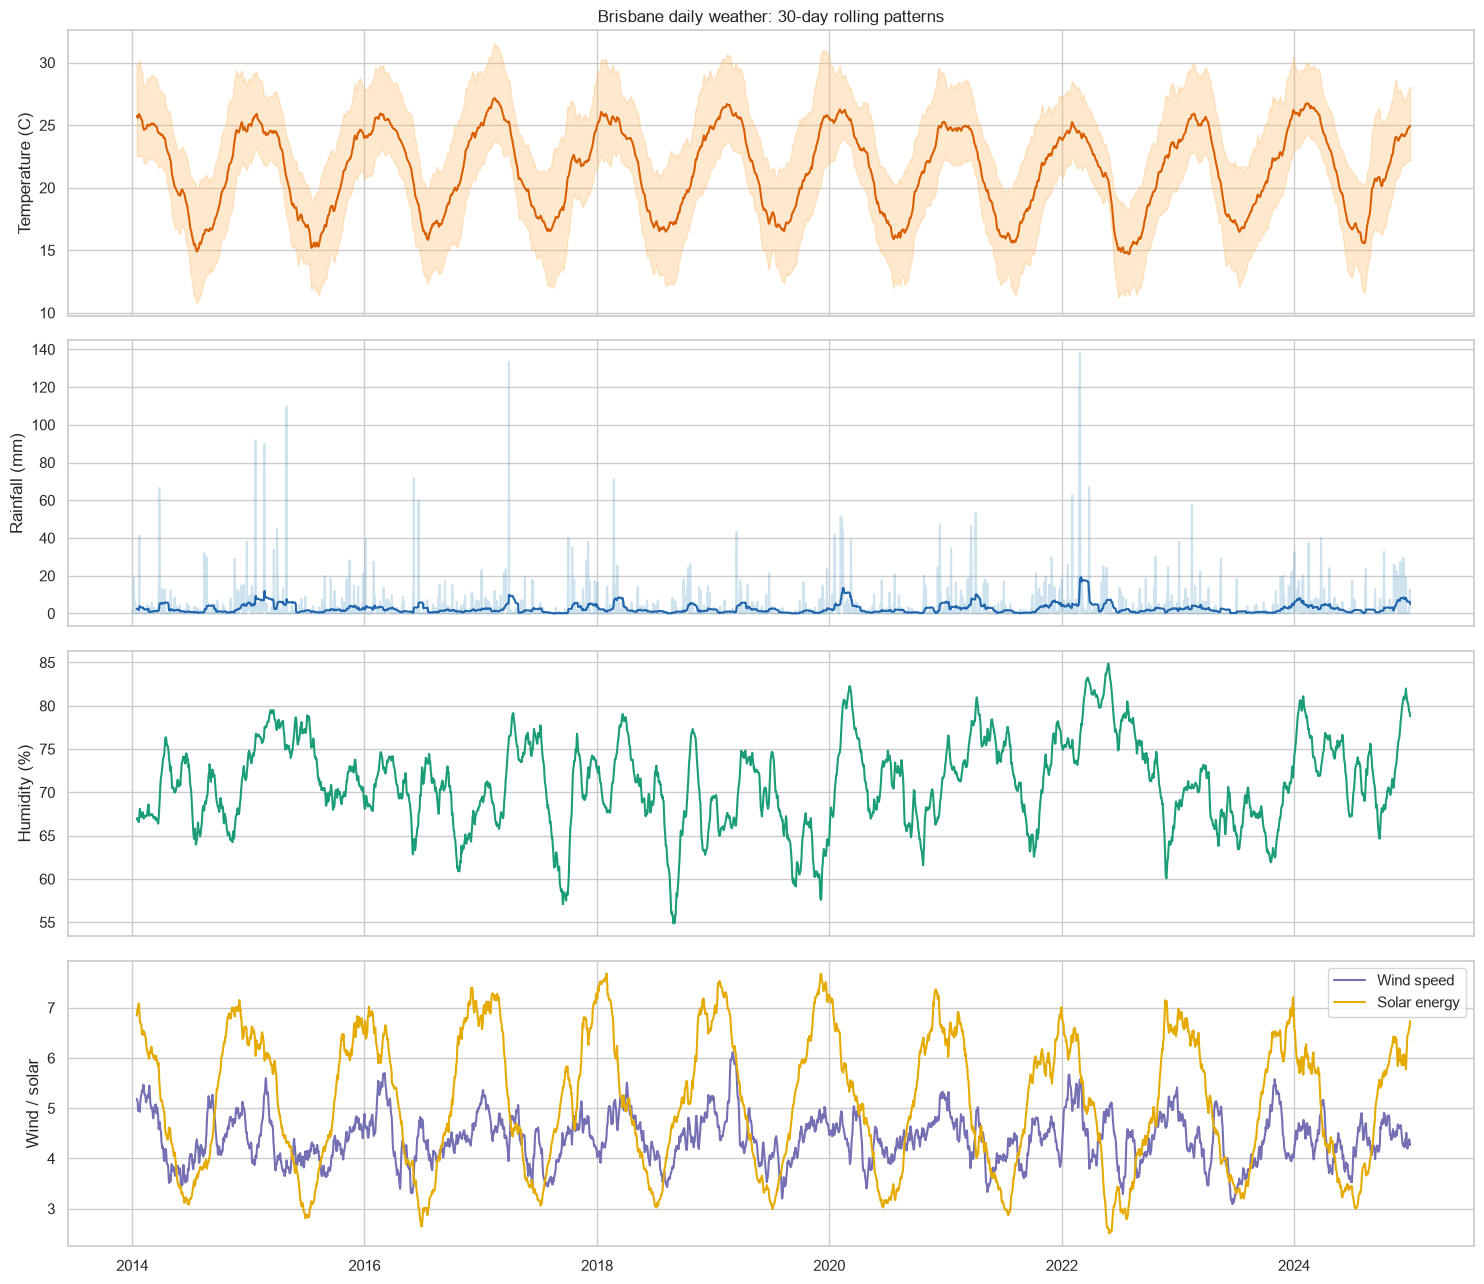

In [5]:
rolling = weather.rolling(30, min_periods=15).mean()

fig, axes = plt.subplots(4, 1, figsize=(15, 13), sharex=True)

axes[0].plot(rolling.index, rolling["temp_mean_c"], color="#d95f02")
axes[0].fill_between(rolling.index, rolling["temp_min_c"], rolling["temp_max_c"], color="#fdb863", alpha=0.3)
axes[0].set_ylabel("Temperature (C)")
axes[0].set_title("Brisbane daily weather: 30-day rolling patterns")

axes[1].plot(weather.index, weather["rainfall_mm"], color="#4393c3", alpha=0.25)
axes[1].plot(rolling.index, rolling["rainfall_mm"], color="#2166ac")
axes[1].set_ylabel("Rainfall (mm)")

axes[2].plot(rolling.index, rolling["humidity_pct"], color="#1b9e77")
axes[2].set_ylabel("Humidity (%)")

axes[3].plot(rolling.index, rolling["wind_speed_ms"], label="Wind speed", color="#7570b3")
axes[3].plot(rolling.index, rolling["solar_kwh_m2"], label="Solar energy", color="#e6ab02")
axes[3].set_ylabel("Wind / solar")
axes[3].legend()

plt.tight_layout()
plt.show()

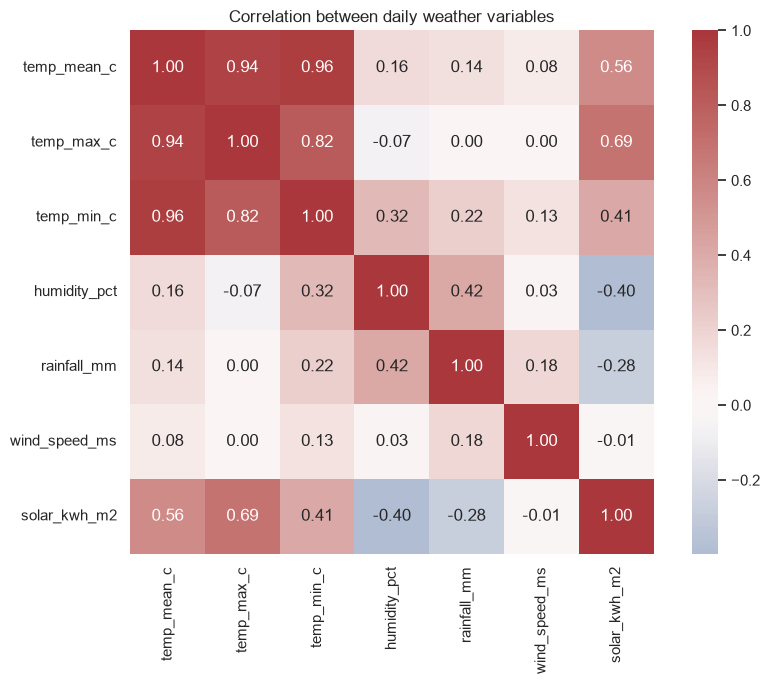

In [6]:
plt.figure(figsize=(9, 7))
sns.heatmap(weather.corr(), annot=True, fmt=".2f", cmap="vlag", center=0, square=True)
plt.title("Correlation between daily weather variables")
plt.tight_layout()
plt.show()

### Exploratory findings

The rolling plots show a strong and repeated annual temperature cycle. Mean temperatures generally peak during summer and fall during winter, while solar energy follows a similar seasonal pattern.

Rainfall is event-driven rather than smoothly seasonal. Most days receive little rainfall, but occasional large spikes occur throughout the record, including particularly intense events around 2017 and 2022. Humidity often rises during wetter periods, while high solar conditions are generally associated with drier air.

Mean, maximum, and minimum temperatures are highly correlated. Mean temperature correlates with minimum temperature at **0.96** and maximum temperature at **0.94**, while maximum and minimum temperatures correlate at **0.82**. Including all three directly would therefore give temperature excessive influence in the HMM.

Maximum temperature has a positive correlation of **0.69** with solar energy. Humidity correlates positively with rainfall at **0.42** and negatively with solar energy at **−0.40**. Rainfall also has a negative correlation of **−0.28** with solar energy. Wind speed has relatively weak correlations with most other variables, meaning it contributes additional information.

## 3. Feature engineering

The HMM uses six complementary weather dimensions:

- mean temperature;
- daily temperature range;
- humidity;
- log-transformed rainfall;
- wind speed;
- solar radiation.

Maximum and minimum temperatures are converted into a temperature-range feature to reduce redundancy with mean temperature.

Rainfall is strongly right-skewed, so `log(1 + rainfall)` is used. Standardisation prevents variables with larger numerical scales from dominating the Gaussian emission distributions.

In [7]:
weather = weather.interpolate(method="time", limit=3).dropna()

features = pd.DataFrame(index=weather.index)
features["Mean temperature"] = weather["temp_mean_c"]
features["Temperature range"] = weather["temp_max_c"] - weather["temp_min_c"]
features["Humidity"] = weather["humidity_pct"]
features["Log rainfall"] = np.log1p(weather["rainfall_mm"].clip(lower=0))
features["Wind speed"] = weather["wind_speed_ms"]
features["Solar energy"] = weather["solar_kwh_m2"]

scaler = StandardScaler()
X = scaler.fit_transform(features)

scaled_features = pd.DataFrame(X, index=features.index, columns=features.columns)

print("Model matrix:", X.shape)
display(features.describe().T.round(2))

Model matrix: (4018, 6)


,count,mean,std,min,25%,50%,75%,max
Mean temperature,4018.0,21.34,3.70,10.20,18.39,21.60,24.43,30.83
Temperature range,4018.0,7.32,2.42,0.96,5.58,7.11,8.90,16.28
Humidity,4018.0,71.10,8.94,33.29,65.83,71.44,77.10,94.04
Log rainfall,4018.0,0.68,0.90,0.00,0.01,0.23,1.11,4.93
Wind speed,4018.0,4.39,1.43,1.24,3.35,4.24,5.26,11.77
Solar energy,4018.0,5.15,1.81,0.55,3.82,5.00,6.65,8.99


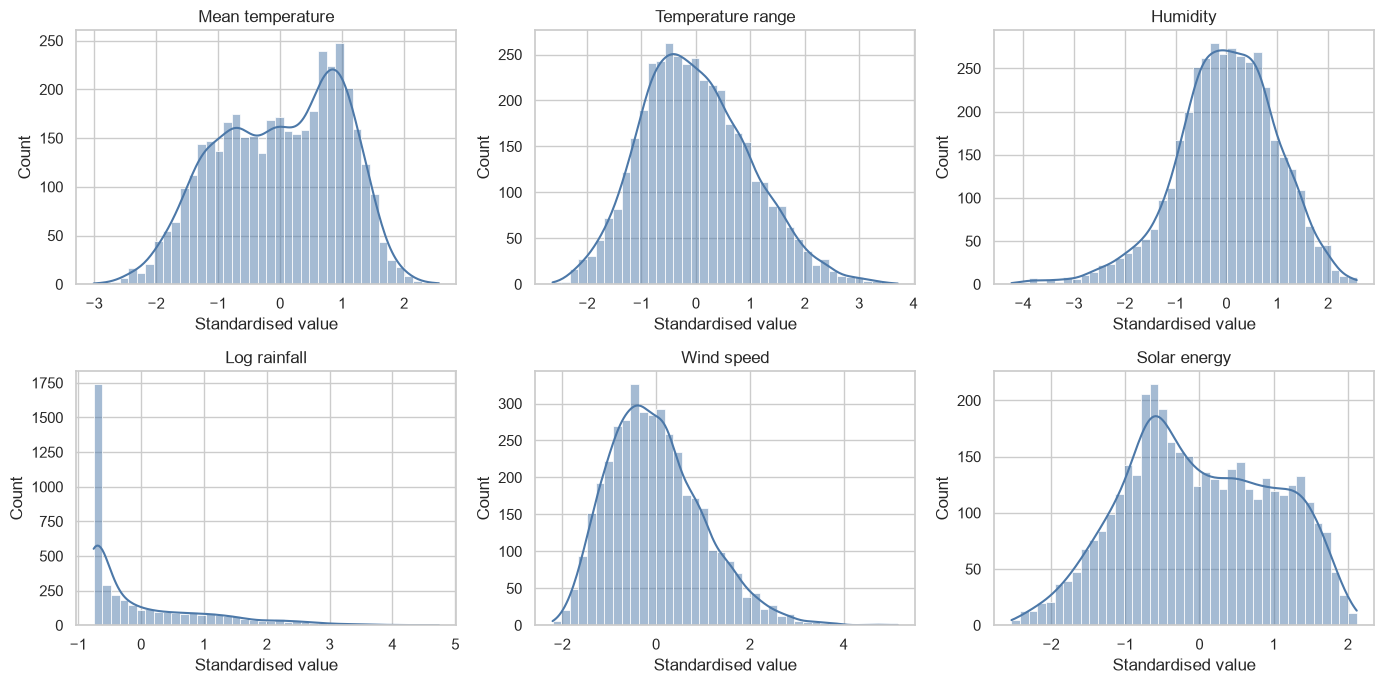

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for column, ax in zip(scaled_features.columns, axes.flat):
    sns.histplot(scaled_features[column], bins=40, kde=True, ax=ax, color="#4c78a8")
    ax.set_title(column)
    ax.set_xlabel("Standardised value")

plt.tight_layout()
plt.show()

Mean temperature retains a broad seasonal distribution, while temperature range is moderately right-skewed. Humidity is approximately unimodal but contains a longer tail toward unusually dry conditions. Wind speed is also right-skewed because very windy days are relatively uncommon.

Applying `log(1 + rainfall)` substantially reduces the scale of extreme rainfall values. However, the transformed variable remains strongly zero-inflated because a large proportion of days receive little or no rainfall. The transformation therefore improves the distribution without making it completely Gaussian.

Solar energy has a broad, partly multimodal distribution reflecting Brisbane's seasonal differences in sunlight. After standardisation, all six features have comparable scales, preventing temperature, humidity, or rainfall from dominating solely because of their original measurement units.

## 4. Gaussian Hidden Markov Model

For every day \(t\), the model assumes an unobserved regime \(z_t\).

The current regime depends on the previous regime:

\[
P(z_t \mid z_{t-1})
\]

The observed weather features are then generated from a regime-specific multivariate Gaussian distribution:

\[
P(x_t \mid z_t)
\]

This allows the model to distinguish persistent weather regimes from isolated groups of similar days.

Models containing two through six regimes are fitted. Each model is trained from three random initialisations because HMM optimisation can converge to different local solutions.

In [9]:
def hmm_parameter_count(k, d):
    return (k - 1) + k * (k - 1) + 2 * k * d

models, selection_rows = {}, []
n, d = X.shape

for k in range(2, 7):
    best_model, best_score = None, -np.inf

    for seed in [11, 29, 47]:
        model = GaussianHMM(
            n_components=k,
            covariance_type="diag",
            n_iter=500,
            tol=1e-4,
            min_covar=1e-3,
            random_state=seed
        )
        model.fit(X)
        score = model.score(X)

        if score > best_score:
            best_model, best_score = model, score

    states = best_model.predict(X)
    state_shares = np.bincount(states, minlength=k) / n
    parameter_count = hmm_parameter_count(k, d)

    models[k] = best_model
    selection_rows.append({
        "regimes": k,
        "log_likelihood": best_score,
        "bic": -2 * best_score + parameter_count * np.log(n),
        "aic": -2 * best_score + 2 * parameter_count,
        "min_state_share": state_shares.min(),
        "converged": best_model.monitor_.converged
    })

model_selection_df = pd.DataFrame(selection_rows)
model_selection_df

Model is not converging.  Current: -26415.930156444472 is not greater than -26415.930067366928. Delta is -8.907754454412498e-05
Model is not converging.  Current: -23548.356130130032 is not greater than -23548.35138043076. Delta is -0.004749699273816077
Model is not converging.  Current: -22522.21384898843 is not greater than -22522.12879189568. Delta is -0.08505709275050322


,regimes,log_likelihood,bic,aic,min_state_share,converged
0,2,-28393.476943,57011.014454,56840.953886,0.355650,True
1,3,-26399.265411,53163.666563,52886.530823,0.247387,True
2,4,-24418.260885,49359.329762,48962.521770,0.209557,True
3,5,-23203.462109,47104.001540,46574.924218,0.125436,True
4,6,-22490.207009,45868.357749,45194.414017,0.080139,True


In [10]:
eligible_models = model_selection_df[model_selection_df["min_state_share"] >= 0.03]
candidate_pool = eligible_models if not eligible_models.empty else model_selection_df

selected_row = candidate_pool.loc[candidate_pool["bic"].idxmin()]
best_k = int(selected_row["regimes"])
best_model = models[best_k]

print(f"Selected number of regimes: {best_k}")
display(selected_row.to_frame("selected_model"))

Selected number of regimes: 6


,selected_model
regimes,6
log_likelihood,-22490.207009
bic,45868.357749
aic,45194.414017
min_state_share,0.080139
converged,True


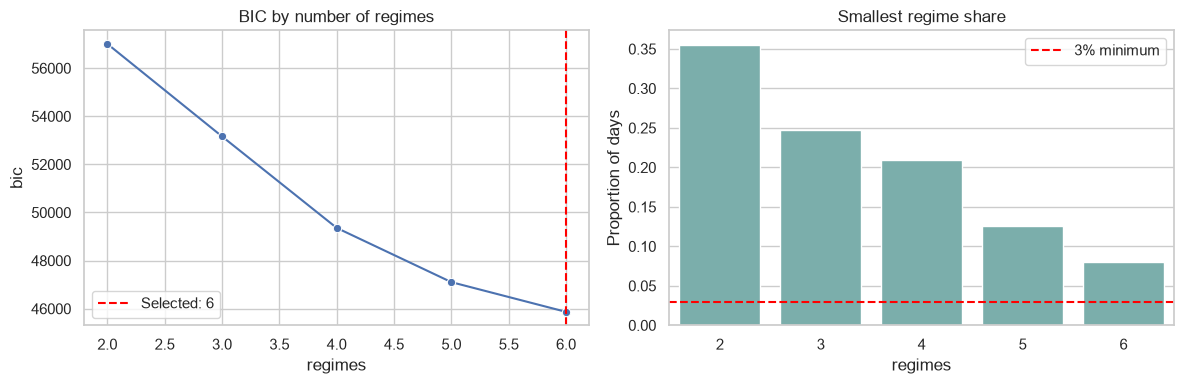

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.lineplot(data=model_selection_df, x="regimes", y="bic", marker="o", ax=axes[0])
axes[0].axvline(best_k, color="red", linestyle="--", label=f"Selected: {best_k}")
axes[0].set_title("BIC by number of regimes")
axes[0].legend()

sns.barplot(data=model_selection_df, x="regimes", y="min_state_share", ax=axes[1], color="#72b7b2")
axes[1].axhline(0.03, color="red", linestyle="--", label="3% minimum")
axes[1].set_title("Smallest regime share")
axes[1].set_ylabel("Proportion of days")
axes[1].legend()

plt.tight_layout()
plt.show()

Among the tested models, the **six-regime HMM** achieved the lowest BIC of approximately **45,868**, compared with 47,104 for five regimes and 49,359 for four regimes. Log-likelihood also improved consistently as additional regimes were introduced.

The smallest state in the six-regime model still contains approximately **8.0% of all days**, comfortably above the 3% threshold. The additional state therefore represents a substantial weather pattern rather than a very small collection of unusual observations.

The retained six-regime model converged successfully. Some discarded random initialisations generated convergence warnings, but the best model selected for each regime count converged.

Because BIC was still decreasing at the upper tested limit, six regimes should be described as the **best solution among the tested models**, rather than proof that six is the absolute global optimum. Nevertheless, its balanced state sizes and interpretable profiles support its use in the remaining analysis.

## 5. Interpret the latent regimes

HMM state numbers are arbitrary. To create a consistent presentation, states are reordered from the lowest to the highest average temperature.

The profiles below show how far each regime lies above or below the overall mean for every feature. Suggested descriptions are generated from the two most distinctive features, but the final names should be chosen after inspecting the complete profiles.

In [27]:
raw_states = best_model.predict(X)
posterior = best_model.predict_proba(X)

temporary = features.assign(raw_state=raw_states)
state_order = temporary.groupby("raw_state")["Mean temperature"].mean().sort_values().index.tolist()
state_map = {old_state: new_state + 1 for new_state, old_state in enumerate(state_order)}

features["regime_id"] = pd.Series(raw_states, index=features.index).map(state_map)
features["regime"] = "R" + features["regime_id"].astype(str)

scaled_features["regime_id"] = features["regime_id"]
profile_z = scaled_features.groupby("regime_id")[scaled_features.columns[:-1]].mean()
profile_z.index = "R" + profile_z.index.astype(str)

In [28]:
friendly_names = {
    "Mean temperature": "temperature",
    "Temperature range": "temperature variation",
    "Humidity": "humidity",
    "Log rainfall": "rainfall",
    "Wind speed": "wind",
    "Solar energy": "solar energy"
}

def describe_regime(row):
    important = row.abs().nlargest(2).index
    parts = [f"{'high' if row[col] >= 0 else 'low'} {friendly_names[col]}" for col in important]
    return " and ".join(parts)

descriptions = profile_z.apply(describe_regime, axis=1)
profile_table = features.groupby("regime")[features.columns[:6]].mean()
profile_table.insert(0, "suggested_description", descriptions)
profile_table["days"] = features["regime"].value_counts()
profile_table["share_pct"] = 100 * profile_table["days"] / len(features)

display(profile_table.round(2))

,suggested_description,Mean temperature,Temperature range,Humidity,Log rainfall,Wind speed,Solar energy,days,share_pct
regime,,,,,,,,,
R1,low temperature and high temperature variation,17.03,9.51,63.85,0.01,3.82,4.43,732,18.22
R2,low solar energy and low temperature,18.43,6.66,75.14,0.63,4.23,3.54,835,20.78
R3,high rainfall and low temperature variation,21.62,3.57,84.13,2.57,5.20,2.65,322,8.01
R4,high solar energy and low humidity,23.20,9.07,63.48,0.01,4.21,7.29,552,13.74
R5,high solar energy and high temperature,23.84,7.71,67.65,0.28,4.74,6.60,693,17.25
R6,high temperature and high rainfall,24.43,6.09,75.99,1.32,4.58,5.68,884,22.00


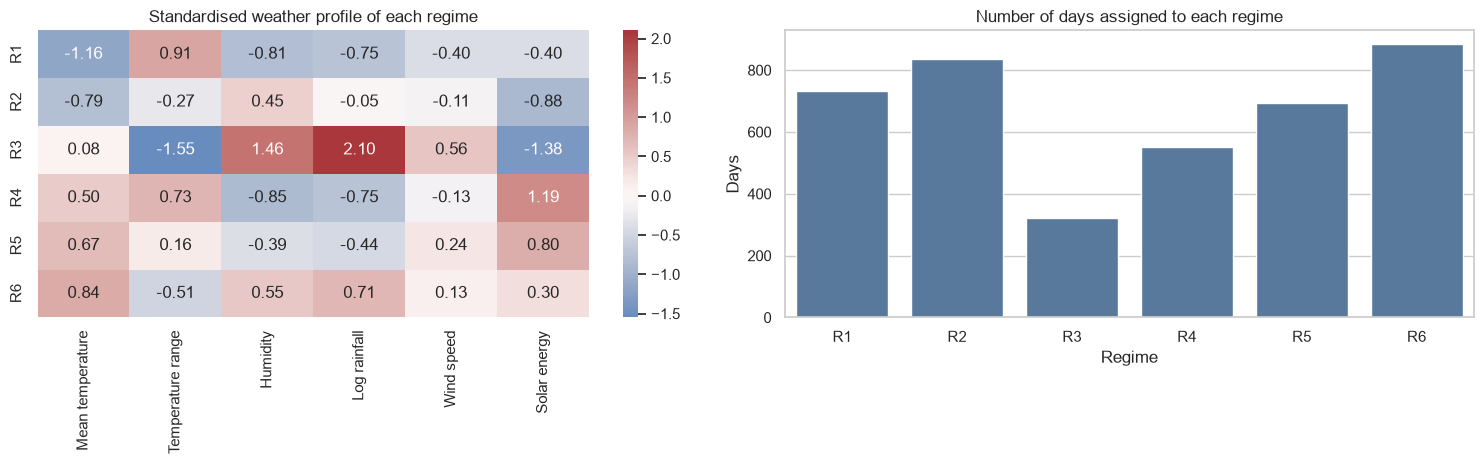

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, max(4, best_k * 0.8)))

sns.heatmap(profile_z, annot=True, fmt=".2f", cmap="vlag", center=0, ax=axes[0])
axes[0].set_title("Standardised weather profile of each regime")
axes[0].set_xlabel("")
axes[0].set_ylabel("")

state_sizes = features["regime"].value_counts().sort_index().rename("days").reset_index()
sns.barplot(data=state_sizes, x="regime", y="days", color="#4c78a8", ax=axes[1])
axes[1].set_title("Number of days assigned to each regime")
axes[1].set_xlabel("Regime")
axes[1].set_ylabel("Days")

plt.tight_layout()
plt.show()

### Regime profile findings

The six latent states can be interpreted as follows:

| Regime | Suggested name | Main characteristics |
|---|---|---|
| R1 | Cool Dry Winter | Lowest mean temperature, largest temperature range, low humidity, almost no rainfall, and below-average solar energy |
| R2 | Cool Humid Winter | Cool, humid, moderately cloudy conditions with a smaller temperature range and the lowest solar energy |
| R3 | Wet Overcast System | Very high rainfall and humidity, highest wind speed, smallest temperature range, and lowest solar energy |
| R4 | Warm Dry High-Sun | Warm, very dry conditions with high solar energy, low humidity, and a large daily temperature range |
| R5 | Hot Sunny and Breezy | Hot, mostly dry and sunny conditions with moderately elevated wind speed |
| R6 | Hot Humid and Showery | Hottest average conditions, elevated humidity and rainfall, moderate solar energy, and a relatively small temperature range |

**R6** is the most common regime, containing **884 days or 22.00%** of the dataset. It is followed by R2 with 835 days, R1 with 732 days, R5 with 693 days, and R4 with 552 days.

R3 is the smallest regime with **322 days or 8.01%**, but it is also the most meteorologically distinctive. Its rainfall score is 2.10 standard deviations above average, humidity is 1.46 standard deviations above average, and solar energy is 1.38 standard deviations below average. This strongly supports its interpretation as a wet and overcast weather system rather than an unnecessary small state.

## 6. Seasonal distribution and historical timeline

The model was not given month or season labels. Therefore, comparing the discovered regimes with calendar months provides an external interpretability check.

A regime may be strongly seasonal, occur throughout the year, or represent short-lived weather systems that cross conventional seasonal boundaries.

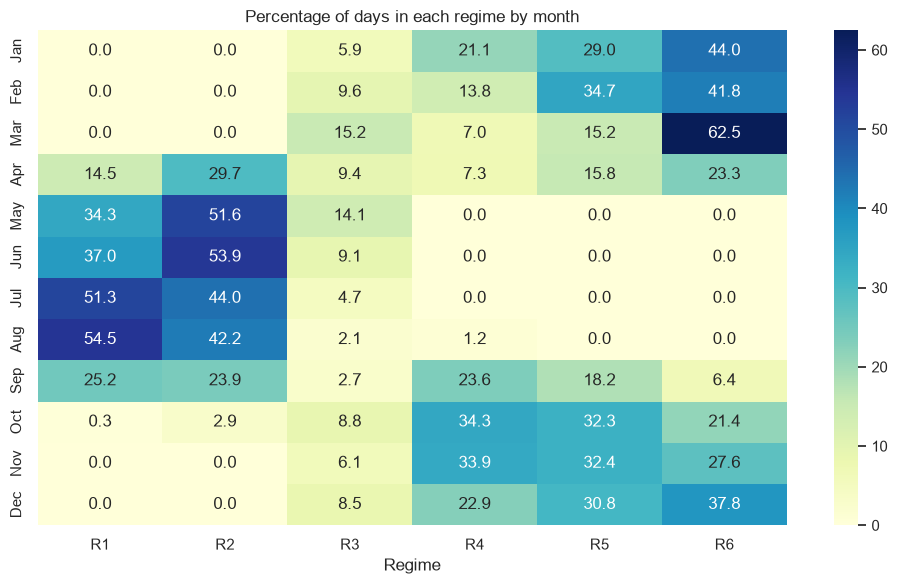

In [15]:
calendar_df = features[["regime"]].copy()
calendar_df["month"] = calendar_df.index.month

month_mix = pd.crosstab(calendar_df["month"], calendar_df["regime"], normalize="index") * 100
month_mix.index = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                   "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

plt.figure(figsize=(10, 6))
sns.heatmap(month_mix, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Percentage of days in each regime by month")
plt.xlabel("Regime")
plt.ylabel("")
plt.tight_layout()
plt.show()

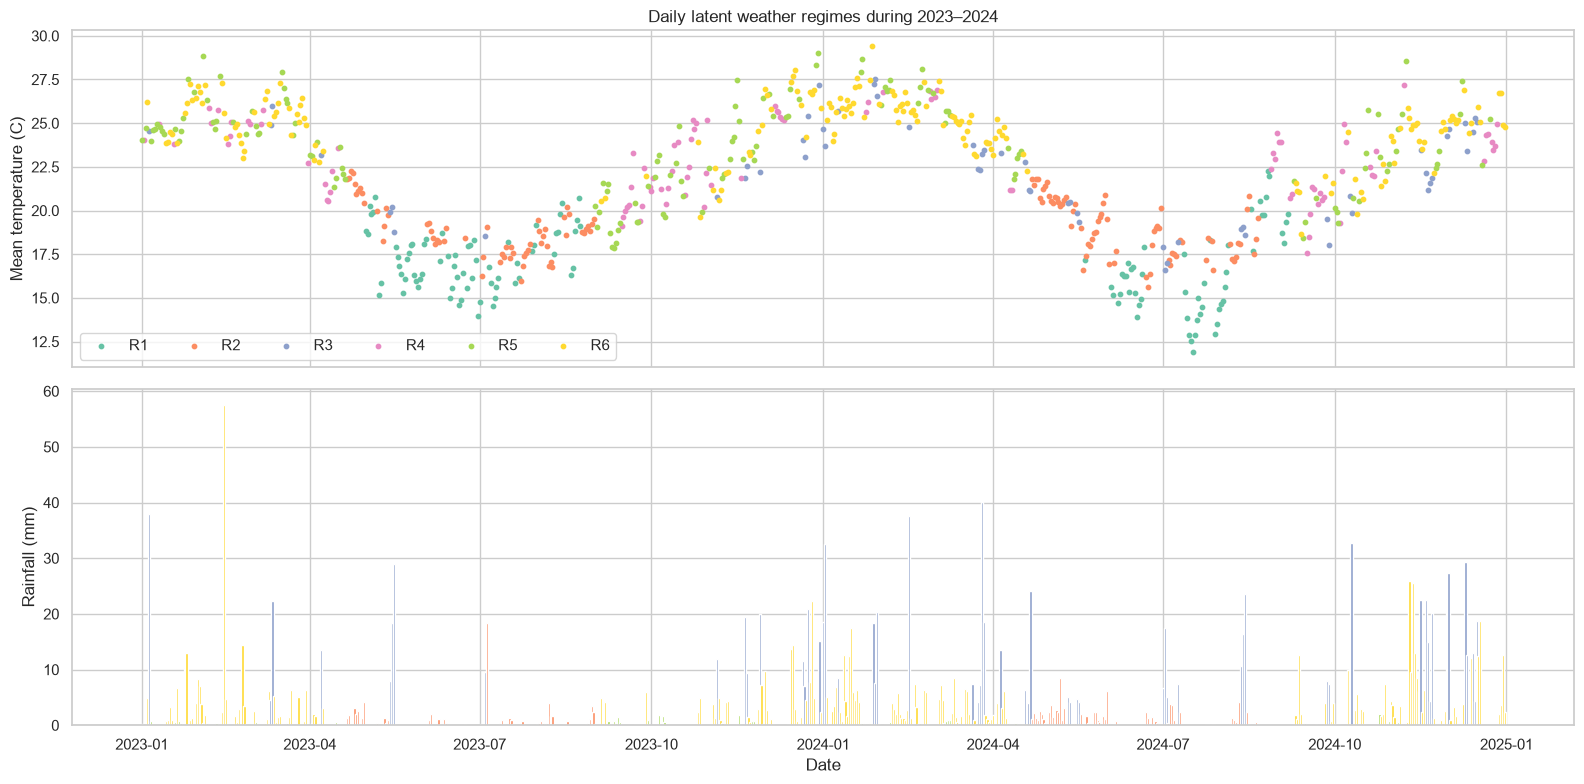

In [16]:
palette = dict(zip(sorted(features["regime"].unique()), sns.color_palette("Set2", best_k)))
timeline = features.loc["2023":"2024"].copy()
timeline["rainfall_mm"] = np.expm1(timeline["Log rainfall"])

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

for regime, group in timeline.groupby("regime"):
    axes[0].scatter(group.index, group["Mean temperature"], s=10, color=palette[regime], label=regime)

axes[0].set_ylabel("Mean temperature (C)")
axes[0].set_title("Daily latent weather regimes during 2023–2024")
axes[0].legend(ncol=best_k)

bar_colours = timeline["regime"].map(palette)
axes[1].bar(timeline.index, timeline["rainfall_mm"], width=1.2, color=bar_colours)
axes[1].set_ylabel("Rainfall (mm)")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()

### Seasonal and timeline 

The discovered regimes have clear seasonal structure despite month information not being supplied to the HMM.

R1 and R2 dominate the cooler months. R1 accounts for **51.3% of July** and **54.5% of August**, representing Brisbane's cool, dry winter days. R2 is most common in May and June, accounting for **51.6% and 53.9%** of days respectively, and represents cooler but more humid and cloudy winter conditions.

R4 and R5 are concentrated in spring and early summer. Together they account for approximately two-thirds of October and November. R4 represents warmer, exceptionally dry and high-sun days, while R5 represents slightly hotter and breezier conditions.

R6 is the main summer regime, accounting for **44.0% of January**, **41.8% of February**, **62.5% of March**, and **37.8% of December**. Its elevated heat, humidity, and rainfall are consistent with Brisbane's humid summer conditions.

R3 occurs in every month rather than matching one season. Its appearance alongside many of the largest rainfall spikes in the 2023–2024 timeline supports its interpretation as an event-based wet-weather regime.

September has the most balanced mixture of regimes, showing its role as a transition between cool winter conditions and the warmer spring regimes.

## 7. Transition and persistence analysis

The transition matrix estimates the probability of tomorrow's regime conditional on today's regime.

Large diagonal probabilities indicate persistent regimes. Off-diagonal probabilities identify common changes between weather states.

Consecutive days in the same regime are also grouped into spells so that observed spell durations can be compared directly.

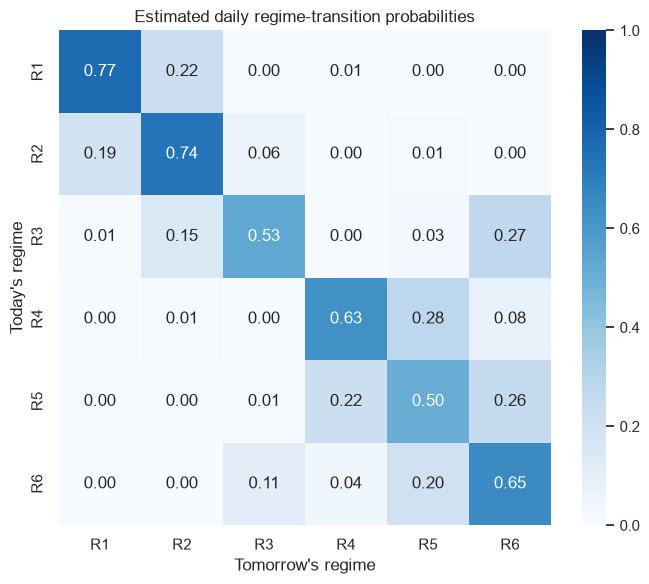

In [17]:
ordered_transition = best_model.transmat_[np.ix_(state_order, state_order)]
regime_labels = [f"R{i}" for i in range(1, best_k + 1)]

transition_df = pd.DataFrame(
    ordered_transition,
    index=regime_labels,
    columns=regime_labels
)

plt.figure(figsize=(7, 6))
sns.heatmap(transition_df, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1)
plt.title("Estimated daily regime-transition probabilities")
plt.xlabel("Tomorrow's regime")
plt.ylabel("Today's regime")
plt.tight_layout()
plt.show()

In [18]:
spell_id = features["regime"].ne(features["regime"].shift()).cumsum()

spell_df = pd.DataFrame({
    "date": features.index,
    "regime": features["regime"].values,
    "spell_id": spell_id.values
})

spells = spell_df.groupby("spell_id").agg(
    regime=("regime", "first"),
    start=("date", "min"),
    end=("date", "max"),
    duration_days=("date", "size")
).reset_index(drop=True)

duration_summary = spells.groupby("regime")["duration_days"].agg(["count", "mean", "median", "max"])
duration_summary["self_transition"] = np.diag(ordered_transition)
duration_summary["hmm_expected_duration"] = 1 / (1 - duration_summary["self_transition"])
duration_summary.round(2)

,count,mean,median,max,self_transition,hmm_expected_duration
regime,,,,,,
R1,164,4.46,3.0,17,0.77,4.29
R2,215,3.88,3.0,19,0.74,3.78
R3,146,2.21,2.0,21,0.53,2.15
R4,202,2.73,2.0,11,0.63,2.68
R5,334,2.07,2.0,10,0.50,2.02
R6,289,3.06,2.0,18,0.65,2.88


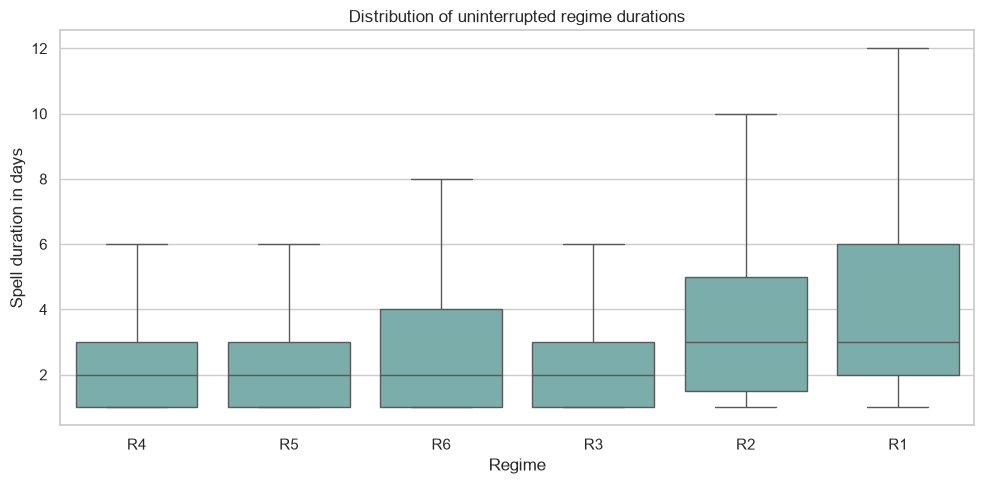

In [19]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=spells, x="regime", y="duration_days", showfliers=False, color="#72b7b2")
plt.title("Distribution of uninterrupted regime durations")
plt.xlabel("Regime")
plt.ylabel("Spell duration in days")
plt.tight_layout()
plt.show()

### Transition and persistence 

R1 is the most persistent regime. It has a self-transition probability of **0.77**, an average uninterrupted duration of **4.46 days**, and a maximum observed spell of 17 days. R2 is the next most persistent, with a self-transition probability of **0.74** and an average duration of 3.88 days.

The transition matrix reveals two main weather families. The cool-weather regimes frequently move between R1 and R2, with probabilities of **0.22 from R1 to R2** and **0.19 from R2 to R1**.

The warm-weather regimes commonly transition through R4, R5, and R6. R4 moves to R5 with probability 0.28, R5 moves to R6 with probability 0.26, and R6 returns to R5 with probability 0.20. This suggests a gradual progression between warm-dry, hot-sunny, and hot-humid conditions.

R3 is less persistent on average, lasting approximately **2.21 days**, which is consistent with a short-lived wet-weather system. It frequently transitions to R6 with probability 0.27 or R2 with probability 0.15, connecting wet systems with both warm-humid and cool-humid conditions.

R5 has the lowest self-transition probability at 0.50 and the largest number of separate spells. It therefore behaves more like an intermediate warm-weather state than a highly persistent regime.

## 8. Posterior uncertainty and rare transitions

An HMM provides a probability for every possible regime on each day.

High maximum posterior probability means that one regime clearly fits the observations. Lower confidence and higher entropy indicate that the day's conditions overlap multiple regimes.

Uncertainty is not necessarily an error. It may represent genuine transitional weather lying between two established regimes.

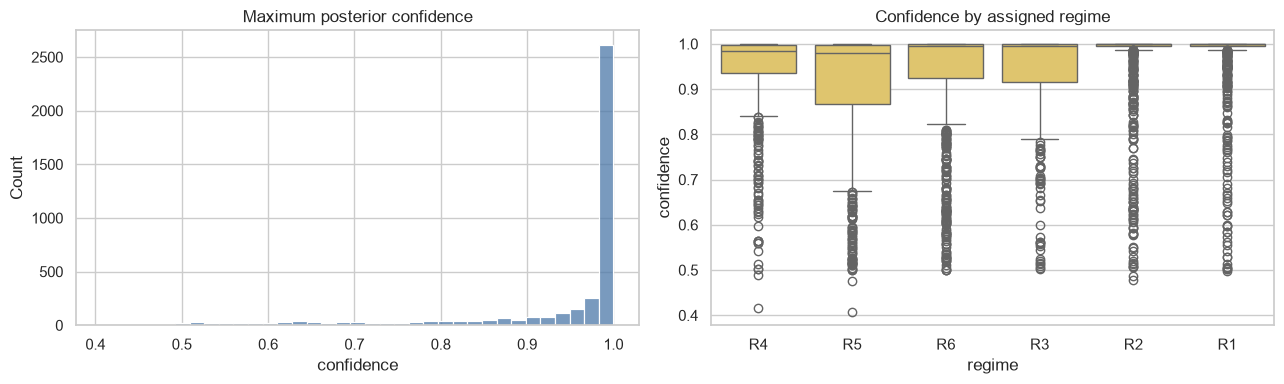

In [20]:
ordered_posterior = posterior[:, state_order]
features["confidence"] = ordered_posterior.max(axis=1)
features["entropy"] = -(ordered_posterior * np.log(ordered_posterior + 1e-12)).sum(axis=1) / np.log(best_k)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(features["confidence"], bins=35, ax=axes[0], color="#4c78a8")
axes[0].set_title("Maximum posterior confidence")

sns.boxplot(data=features, x="regime", y="confidence", ax=axes[1], color="#f2cf5b")
axes[1].set_title("Confidence by assigned regime")

plt.tight_layout()
plt.show()

In [21]:
uncertain_days = weather.join(features[["regime", "confidence", "entropy"]])
uncertain_days = uncertain_days.nsmallest(12, "confidence")

uncertain_days[[
    "regime", "confidence", "entropy", "temp_mean_c",
    "humidity_pct", "rainfall_mm", "wind_speed_ms", "solar_kwh_m2"
]].round(3)

,regime,confidence,entropy,temp_mean_c,humidity_pct,rainfall_mm,wind_speed_ms,solar_kwh_m2
date,,,,,,,,
2015-04-16,R5,0.408,0.811,21.94,75.59,0.01,2.77,5.288
2015-03-03,R4,0.416,0.600,24.33,75.84,0.03,3.86,7.165
2016-03-29,R5,0.476,0.576,24.91,69.07,0.01,2.56,6.100
2022-04-30,R2,0.479,0.487,21.97,82.22,0.63,2.57,4.156
2016-05-02,R2,0.487,0.553,22.81,83.20,2.97,2.28,3.273
2015-03-19,R4,0.489,0.520,26.16,73.99,0.00,4.67,6.045
2018-09-16,R1,0.499,0.411,20.18,58.24,0.03,6.08,5.751
2016-10-22,R6,0.500,0.387,22.55,69.33,1.94,5.18,5.935
2024-02-04,R5,0.501,0.387,26.82,76.83,0.22,3.31,5.037


In [22]:
state_sequence = features["regime_id"].to_numpy() - 1
previous_state, current_state = state_sequence[:-1], state_sequence[1:]

transition_events = pd.DataFrame({
    "date": features.index[1:],
    "from_regime": [regime_labels[i] for i in previous_state],
    "to_regime": [regime_labels[i] for i in current_state],
    "surprise": -np.log(ordered_transition[previous_state, current_state] + 1e-12)
})

transition_events = transition_events[
    transition_events["from_regime"] != transition_events["to_regime"]
]

top_surprising_transitions = (
    transition_events.sort_values("surprise", ascending=False)
    .head(12)
    .merge(weather.reset_index(), on="date", how="left")
)

top_surprising_transitions.round(3)

,date,from_regime,to_regime,surprise,temp_mean_c,temp_max_c,temp_min_c,humidity_pct,rainfall_mm,wind_speed_ms,solar_kwh_m2
0,2022-09-21,R4,R3,6.912,19.39,21.58,17.58,80.02,2.44,4.57,2.586
1,2024-09-03,R4,R1,6.058,18.74,22.56,15.81,53.18,0.00,6.55,5.968
2,2018-10-30,R3,R4,5.570,20.94,24.73,17.51,66.54,0.01,3.85,7.081
3,2023-04-21,R5,R2,5.484,21.82,25.71,18.83,70.31,1.23,7.49,3.855
4,2015-09-26,R5,R2,5.484,17.62,21.17,14.42,75.99,2.81,5.71,4.990
5,2019-09-13,R1,R4,4.757,19.23,27.45,12.70,52.92,0.00,4.72,6.142
6,2024-09-07,R1,R4,4.757,20.70,26.72,15.88,67.30,0.00,4.34,5.977
7,2017-09-19,R1,R4,4.757,20.68,27.14,14.95,62.68,0.00,4.79,6.161
8,2024-08-28,R1,R4,4.757,22.40,28.86,17.37,67.92,0.00,4.78,5.511
9,2021-09-10,R1,R4,4.757,19.68,27.72,13.34,62.04,0.00,3.09,6.295


### Uncertainty findings

Posterior confidence is generally very high, with most daily assignments close to a probability of 1. This indicates that the six regimes are usually well separated.

R1 and R2 have especially confident assignments, while R5 shows the widest confidence distribution and the greatest overlap with neighbouring warm-weather regimes. This agrees with its role as an intermediate state between the dry R4 and humid R6 regimes.

The lowest-confidence observation occurred on **16 April 2015**, when R5 was assigned with a probability of only **0.408** and normalised entropy reached 0.811. Its moderate temperature, relatively high humidity, low rainfall, low wind, and moderate solar energy do not strongly match one individual regime.

Most uncertain days occur around March–May or September–October, when Brisbane is moving between seasonal weather patterns. Their values are meteorologically plausible and do not suggest obvious data errors.

The most surprising transition was from R4 to R3 on **21 September 2022**, representing a rapid change from warm, dry, sunny conditions to a wet and overcast system. Other rare changes include R4 to R1, R3 to R4, and R5 to R2. These events are concentrated around transitional months and represent abrupt but realistic weather changes rather than necessarily anomalous observations.